Expt No: 4- Probabilistic Classification using Naïve Bayes

Scenario 1 – Multinomial Naive Bayes

Preethi R

24BAD091

SCENARIO 1 – MULTINOMIAL NAÏVE BAYES

Problem Statement
Classify SMS messages as Spam or Ham (Not Spam)..

Dataset (Kaggle – Public)
https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset

Target Variable: Message Label (Spam / Ham)
Input Feature: SMS Text Messages


Scenario 1 – Multinomial Naive Bayes
Name    : Preethi R
Roll No : 24BAD091


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.



Dataset Loaded Successfully
Dataset Shape: (5572, 2)

Class Distribution:
 label
ham     4825
spam     747
Name: count, dtype: int64

MODEL PERFORMANCE
Accuracy : 0.9704035874439462
Precision: 0.8625
Recall   : 0.9261744966442953
F1 Score : 0.8932038834951457


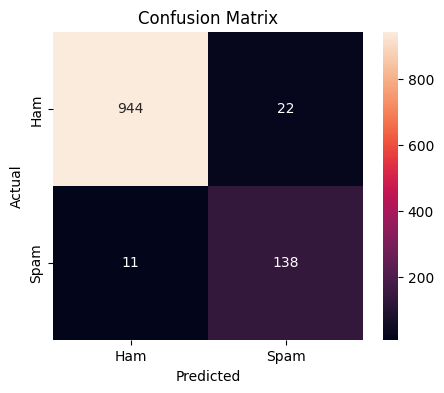


Number of Misclassified Messages: 33

Sample Misclassified Messages:
     Actual Predicted                                            message
5      spam       ham  FreeMsg Hey there darling it's been 3 week's n...
3979   spam       ham                                 ringtoneking 84484
3358   spam       ham  Sorry I missed your call let's talk when you h...
847     ham      spam  I am in office:)whats the matter..msg me now.i...
4801    ham      spam      Reverse is cheating. That is not mathematics.
4942    ham      spam  Check mail.i have mailed varma and kept copy t...
2635    ham      spam       Tiwary to rcb.battle between bang and kochi.
3601    ham      spam     Cps is causing the outages to conserve energy.
2569    ham      spam           Ultimately tor motive tui achieve korli.
665     ham      spam  En chikku nange bakra msg kalstiya..then had t...

Accuracy with alpha=1.0 : 0.9704035874439462
Accuracy with alpha=0.1 : 0.9713004484304932


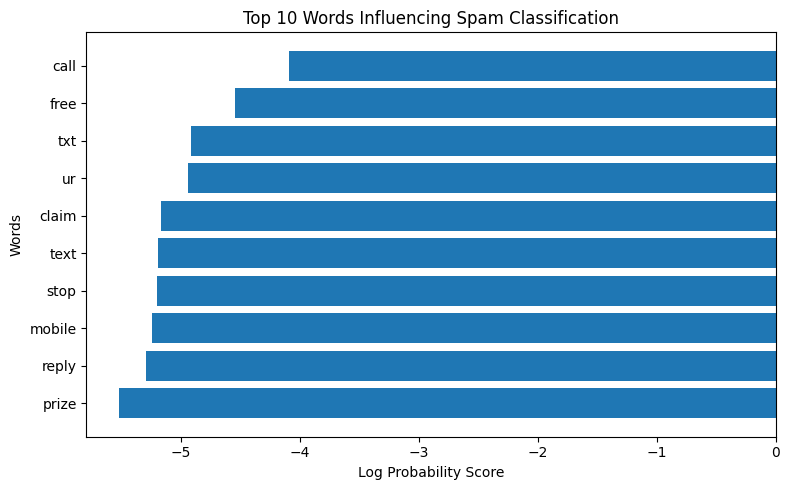

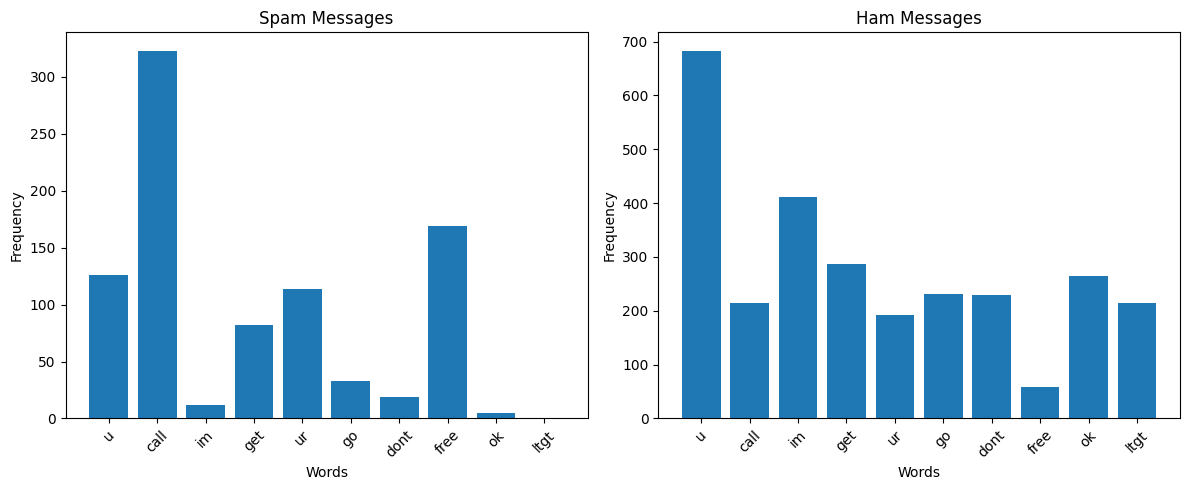

In [1]:
print("Scenario 1 – Multinomial Naive Bayes")
print("Name    : Preethi R")
print("Roll No : 24BAD091")

# Import Required Libraries
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

# Load Dataset
df = pd.read_csv("spam.csv", encoding='latin-1')
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

print("\nDataset Loaded Successfully")
print("Dataset Shape:", df.shape)
print("\nClass Distribution:\n", df['label'].value_counts())

# Text Preprocessing
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

df['clean_message'] = df['message'].apply(clean_text)

# Convert Text to Numerical Features
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df['clean_message'])

# Encode Target Labels
encoder = LabelEncoder()
y = encoder.fit_transform(df['label'])   # ham=0, spam=1

# Train-Test Split
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, df.index,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Train Multinomial Naïve Bayes Model
model = MultinomialNB(alpha=1.0)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Model Evaluation
print("\nMODEL PERFORMANCE")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='rocket',
            xticklabels=['Ham','Spam'],
            yticklabels=['Ham','Spam'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Misclassified Messages (Fixed Properly)
test_df = df.loc[idx_test].copy()
test_df['Actual'] = encoder.inverse_transform(y_test)
test_df['Predicted'] = encoder.inverse_transform(y_pred)

misclassified = test_df[test_df['Actual'] != test_df['Predicted']]

print("\nNumber of Misclassified Messages:", len(misclassified))
print("\nSample Misclassified Messages:")
print(misclassified[['Actual','Predicted','message']].head(10))

# Laplace Smoothing Impact
model2 = MultinomialNB(alpha=0.1)
model2.fit(X_train, y_train)
y_pred2 = model2.predict(X_test)

print("\nAccuracy with alpha=1.0 :", accuracy_score(y_test, y_pred))
print("Accuracy with alpha=0.1 :", accuracy_score(y_test, y_pred2))

# Feature Importance (Top 10 Spam Words)
feature_names = vectorizer.get_feature_names_out()
spam_log_probs = model.feature_log_prob_[1]

top_n = 10
top_indices = np.argsort(spam_log_probs)[-top_n:]
top_words = feature_names[top_indices]
top_scores = spam_log_probs[top_indices]

plt.figure(figsize=(8,5))
plt.barh(top_words, top_scores)
plt.xlabel("Log Probability Score")
plt.ylabel("Words")
plt.title("Top 10 Words Influencing Spam Classification")
plt.tight_layout()
plt.show()

# Word Frequency Comparison (Spam vs Ham)

all_words = " ".join(df['clean_message'])

top_words = pd.Series(all_words.split()) \
            .value_counts() \
            .head(10) \
            .index

spam_counts = []
ham_counts = []

for word in top_words:
    spam_counts.append(
        df[df['label']=='spam']['clean_message']
        .str.contains(r'\b'+word+r'\b')
        .sum()
    )

    ham_counts.append(
        df[df['label']=='ham']['clean_message']
        .str.contains(r'\b'+word+r'\b')
        .sum()
    )

plt.figure(figsize=(12,5))

# Spam Graph
plt.subplot(1,2,1)
plt.bar(top_words, spam_counts)
plt.xticks(rotation=45)
plt.title("Spam Messages")
plt.xlabel("Words")
plt.ylabel("Frequency")

# Ham Graph
plt.subplot(1,2,2)
plt.bar(top_words, ham_counts)
plt.xticks(rotation=45)
plt.title("Ham Messages")
plt.xlabel("Words")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

Code Explanation:

Step 1: Importing Required Libraries

    In this step, we imported all required libraries
    • pandas and numpy for data handling.
    • re and string for text cleaning.
    • matplotlib and seaborn for visualization.
    • From sklearn:
        o CountVectorizer for text-to-number conversion.
        o train_test_split for splitting data.
        o LabelEncoder for encoding labels.
        o MultinomialNB for building the model.
        o Evaluation metrics for performance measurement.
    • NLTK stopwords for removing common words.

Step 2: Loading the Dataset

    In this step, we loaded spam.csv using pandas.
      • Selected columns v1 (label) and v2 (message).
      • Renamed them as label and message.
      • Displayed dataset shape and class distribution.
    This helps understand spam and ham count.

Step 3: Text Preprocessing

    In this step, we cleaned the text data.
      • Converted text to lowercase.
      • Removed numbers and punctuation.
      • Removed stopwords.
    We created a new column clean_message after preprocessing.

Step 4: Converting Text to Numerical Features

    In this step, we used CountVectorizer.
      • Converted cleaned text into word frequency matrix (Bag of Words).
      • This makes text suitable for machine learning.

Step 5: Encoding Target Labels

    In this step, we used LabelEncoder.
      • ham → 0
      • spam → 1
    This converts categorical labels into numeric form.

Step 6: Train-Test Splitting

    In this step, we split the data into:
      • 80% training
      • 20% testing
    Used stratify=y to maintain class balance.

Step 7: Training the Model

    In this step, we trained the Multinomial Naïve Bayes model.
      • Used alpha = 1.0 for Laplace smoothing.

Step 8: Making Predictions

    In this step, we predicted spam or ham using the trained model.

Step 9: Model Evaluation

    In this step, we evaluated using:
      • Accuracy
      • Precision
      • Recall
      • F1 Score
    These measure model performance.

Step 10: Confusion Matrix

    In this step, we generated a confusion matrix.
      • Shows TP, TN, FP, FN.
      • Visualized using heatmap.

Step 11: Identifying Misclassified Messages

    In this step, we displayed incorrectly predicted messages.
    This helps analyze errors.

Step 12: Comparing Laplace Smoothing

    In this step, we compared:
      • alpha = 1.0
      • alpha = 0.1
    To observe smoothing impact.

Step 13: Feature Importance

    In this step, we extracted top 10 spam words.
      • Plotted bar graph to show influential words.

Step 14: Word Frequency Comparison

    In this step, we compared word frequency in:
      • Spam messages
      • Ham messages
    This shows distribution differences.

SCENARIO 2 – GAUSSIAN NAÏVE BAYES

Problem Statement
Classify flower species based on physical measurements.

Dataset (Public / Standard Dataset)
Iris Dataset (sklearn)

Target Variable: Flower Species
Input Features
• Sepal Length
• Sepal Width
• Petal Length
• Petal Width


Scenario 2 – Gaussian Naïve Bayes (Iris Dataset)
Preethi R
24BAD091

Class Labels: ['setosa' 'versicolor' 'virginica']

First 5 Rows of Dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  Species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  

Dataset Shape: (150, 5)

Missing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
Species              0
dtype: int64

Model Evaluation:
Accuracy: 0.9666666666666667

Classification Report:
              precision    recall  f1-score   support

      setos

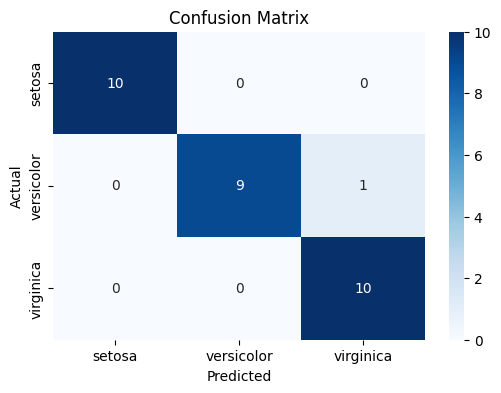

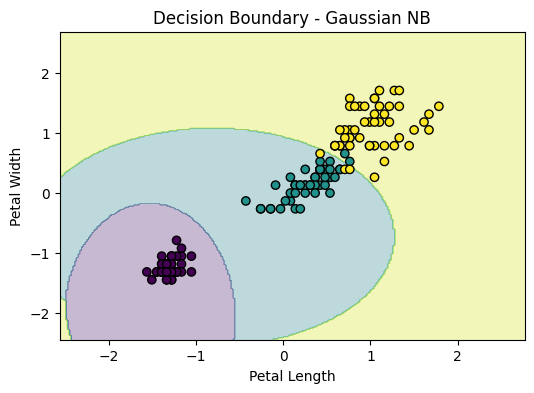

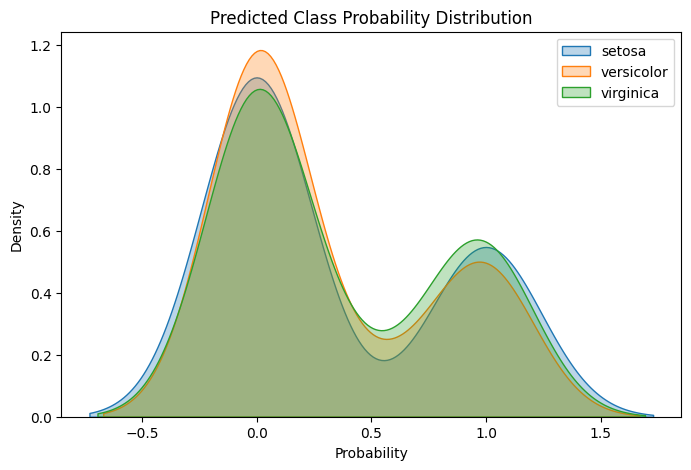


Logistic Regression Accuracy: 0.9333333333333333


In [2]:
print("Scenario 2 – Gaussian Naïve Bayes (Iris Dataset)")
print("Preethi R")
print("24BAD091")

# Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# Load Dataset

iris = load_iris()
X = iris.data
y = iris.target

feature_names = iris.feature_names
target_names = iris.target_names

print("\nClass Labels:", target_names)

df = pd.DataFrame(X, columns=feature_names)
df['Species'] = [target_names[i] for i in y]

print("\nFirst 5 Rows of Dataset:")
print(df.head())

# Data Inspection

print("\nDataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

# Feature Scaling

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-Test Split (Stratified)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# Train Gaussian Naïve Bayes

gnb = GaussianNB()
gnb.fit(X_train, y_train)

# Prediction

y_pred = gnb.predict(X_test)

# Evaluation

print("\nModel Evaluation:")
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))

# Compare Predictions (with class names)

comparison = pd.DataFrame({
    "Actual": [target_names[i] for i in y_test],
    "Predicted": [target_names[i] for i in y_pred]
})

print("\nActual vs Predicted (First 10 Rows):")
print(comparison.head(10))

# Class Probabilities

probs = gnb.predict_proba(X_test)
prob_df = pd.DataFrame(probs, columns=target_names)

print("\nClass Probabilities (First 5 Rows):")
print(prob_df.head())

# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, cmap="Blues",
            xticklabels=target_names,
            yticklabels=target_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Decision Boundary (Using Petal Length & Petal Width)

X_2 = X_scaled[:, 2:4]

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_2, y, test_size=0.2, random_state=42, stratify=y
)

model2 = GaussianNB()
model2.fit(X_train2, y_train2)

x_min, x_max = X_2[:, 0].min() - 1, X_2[:, 0].max() + 1
y_min, y_max = X_2[:, 1].min() - 1, X_2[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

Z = model2.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(6,4))
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_2[:, 0], X_2[:, 1], c=y, cmap='viridis', edgecolor='k')
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Decision Boundary - Gaussian NB")
plt.show()

# Predicted Class Probability Distribution

plt.figure(figsize=(8,5))
for species in target_names:
    sns.kdeplot(prob_df[species], label=species, fill=True, alpha=0.3)

plt.xlabel("Probability")
plt.ylabel("Density")
plt.title("Predicted Class Probability Distribution")
plt.legend()
plt.show()

# Optional: Compare with Logistic Regression

lr = LogisticRegression(max_iter=200)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("\nLogistic Regression Accuracy:",
      accuracy_score(y_test, y_pred_lr))


Code Explanation:

Step 1: Importing Required Libraries

    In this step, we imported all required libraries.
    • numpy and pandas for data handling and numerical operations.
    • matplotlib and seaborn for visualization.
    • From sklearn:
      o load_iris to load the Iris dataset.
      o train_test_split for splitting data.
      o StandardScaler for feature scaling.
      o GaussianNB for building the Naïve Bayes model.
      o LogisticRegression for comparison.
      o accuracy_score, classification_report, and confusion_matrix for evaluation.

Step 2: Loading the Dataset

    In this step, we loaded the Iris dataset using load_iris().
    • Extracted features (X) and target labels (y).
    • Stored feature names and class names.
    • Created a DataFrame for better visualization.
    • Displayed first 5 rows of the dataset.
    This helps understand the structure of the dataset.

Step 3: Data Inspection

    In this step, we checked:
    • Dataset shape (number of rows and columns).
    • Missing values in the dataset.
    This ensures the dataset is clean and ready for modeling.

Step 4: Feature Scaling

    In this step, we used StandardScaler.
    • Standardized features to have mean = 0 and variance = 1.
    • This improves Gaussian Naïve Bayes performance.

Step 5: Train-Test Splitting

    In this step, we split the dataset into:
    • 80% training data
    • 20% testing data
    Used stratify=y to maintain equal class distribution.

Step 6: Training the Model

    In this step, we trained the Gaussian Naïve Bayes model using training data.
    • The model assumes features follow a normal (Gaussian) distribution.

Step 7: Making Predictions

    In this step, we predicted the class labels for the test data using the trained model.

Step 8: Model Evaluation

    In this step, we evaluated the model using:
    • Accuracy
    • Classification Report (Precision, Recall, F1 Score)
    These metrics measure model performance.

Step 9: Comparing Actual and Predicted Values

    In this step, we created a comparison table showing:
    • Actual class labels
    • Predicted class labels
    This helps visually verify predictions.

Step 10: Class Probabilities

    In this step, we calculated predicted probabilities using predict_proba().
    • Shows probability of each class for test samples.
    This indicates model confidence.

Step 11: Confusion Matrix

    In this step, we generated a confusion matrix.
    • Shows correct and incorrect predictions.
    • Visualized using heatmap.

Step 12: Decision Boundary Visualization

    In this step, we plotted the decision boundary using:
    • Petal Length
    • Petal Width
    This shows how Gaussian NB separates different classes.

Step 13: Probability Distribution Plot

    In this step, we plotted KDE graphs of predicted class probabilities.
    • Shows distribution of prediction confidence for each species.

Step 14: Model Comparison

    In this step, we compared Gaussian Naïve Bayes with Logistic Regression.
    • Trained Logistic Regression model.
    • Compared accuracy values.
    This helps analyze performance differences.